In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from src.data_loader import get_prices
from src.backtest import run_backtest
from src.rolling_factor import rolling_alpha_beta
from src.stability import stability_score

In [3]:
tickers = ["AAPL", "TSLA", "SPY"]
prices = get_prices(tickers)

portfolio_returns, weights, regimes = run_backtest(
    prices,
    window=60,
    rebalance_freq=21,
    transaction_cost=0.001
)

[*********************100%***********************]  3 of 3 completed


In [4]:
market_returns = prices["SPY"].pct_change().dropna()

market_returns = market_returns.iloc[-len(portfolio_returns):]
portfolio_returns = portfolio_returns.reset_index(drop=True)
market_returns = market_returns.reset_index(drop=True)

In [5]:
rolling_factors = rolling_alpha_beta(
    portfolio_returns,
    market_returns,
    window=60
)

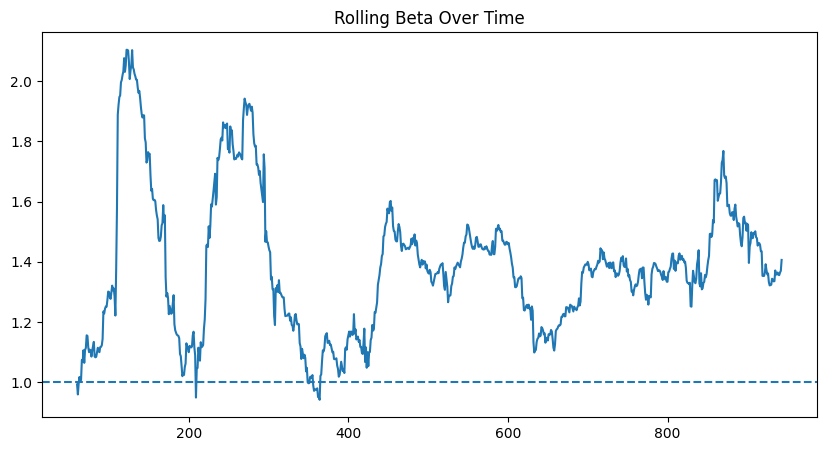

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(rolling_factors["beta"])
plt.title("Rolling Beta Over Time")
plt.axhline(1, linestyle="--")
plt.show()

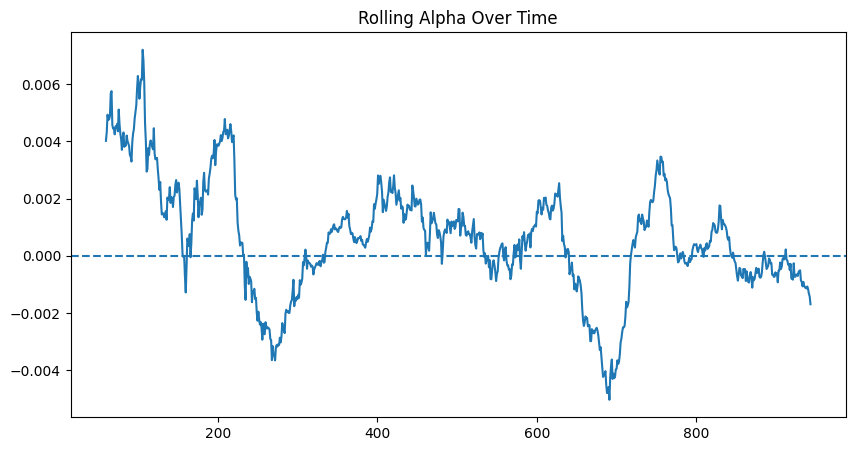

In [7]:
plt.figure(figsize=(10,5))
plt.plot(rolling_factors["alpha"])
plt.title("Rolling Alpha Over Time")
plt.axhline(0, linestyle="--")
plt.show()

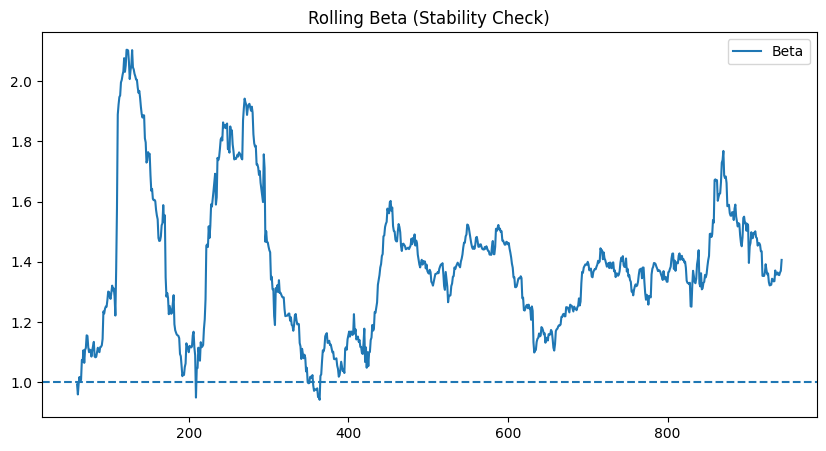

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(rolling_factors["beta"], label="Beta")
plt.title("Rolling Beta (Stability Check)")
plt.axhline(1, linestyle="--")
plt.legend()
plt.show()

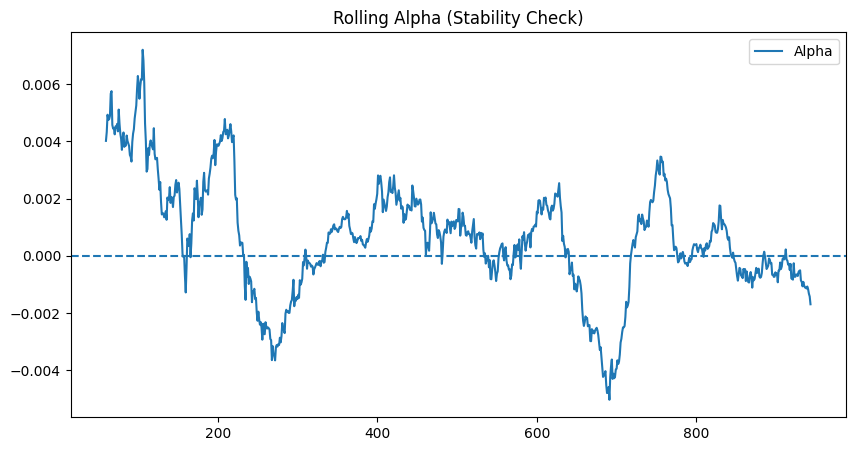

In [9]:
plt.figure(figsize=(10,5))
plt.plot(rolling_factors["alpha"], label="Alpha")
plt.title("Rolling Alpha (Stability Check)")
plt.axhline(0, linestyle="--")
plt.legend()
plt.show()